In [1]:
import json
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

def load_and_verify_data(base_path):
    # Load area mapping
    with open(os.path.join(base_path, "area_code", "area_code.json"), 'r', encoding='utf-8') as f:
        areas = json.load(f)['areas']
    
    dataset = []
    for area in areas:
        code = str(area['code'])
        row = {'area_code': code, 'area_name': area['name']}
        try:
            mp_path = os.path.join(base_path, "mp", f"{code}.json")
            pl_path = os.path.join(base_path, "pl", f"{code}.json")
            
            if os.path.exists(mp_path) and os.path.exists(pl_path):
                with open(mp_path, 'r', encoding='utf-8') as f_mp, \
                     open(pl_path, 'r', encoding='utf-8') as f_pl:
                    mp_data, pl_data = json.load(f_mp), json.load(f_pl)
                
                # Extract Top 10 Features
                for i in range(1, 11):
                    cand = next((e for e in mp_data['entries'] if int(str(e['candidateCode'])[-2:]) == i), None)
                    row[f'mp_{i}'] = cand['votePercent'] if cand else 0.0
                    row[f'mp_party_{i}'] = cand['partyCode'] if cand else None
                    
                    party = next((e for e in pl_data['entries'] if int(e['partyCode'].split('-')[-1]) == i), None)
                    row[f'pl_{i}'] = party['votePercent'] if party else 0.0
                
                # Map actual party votes for Loyalty Analysis (Hypothesis 2)
                pl_lookup = {e['partyCode']: e['votePercent'] for e in pl_data['entries']}
                for i in range(1, 11):
                    actual_p_code = row.get(f'mp_party_{i}')
                    row[f'actual_pl_vote_{i}'] = pl_lookup.get(actual_p_code, 0.0)
                
                dataset.append(row)
        except: continue
    return pd.DataFrame(dataset).fillna(0)

# Initialize Data
BASE_PATH = r"C:\Users\New\OneDrive\Desktop\jupyter\AppliedML\project\election_69_analyzer-master\data"
df = load_and_verify_data(BASE_PATH)

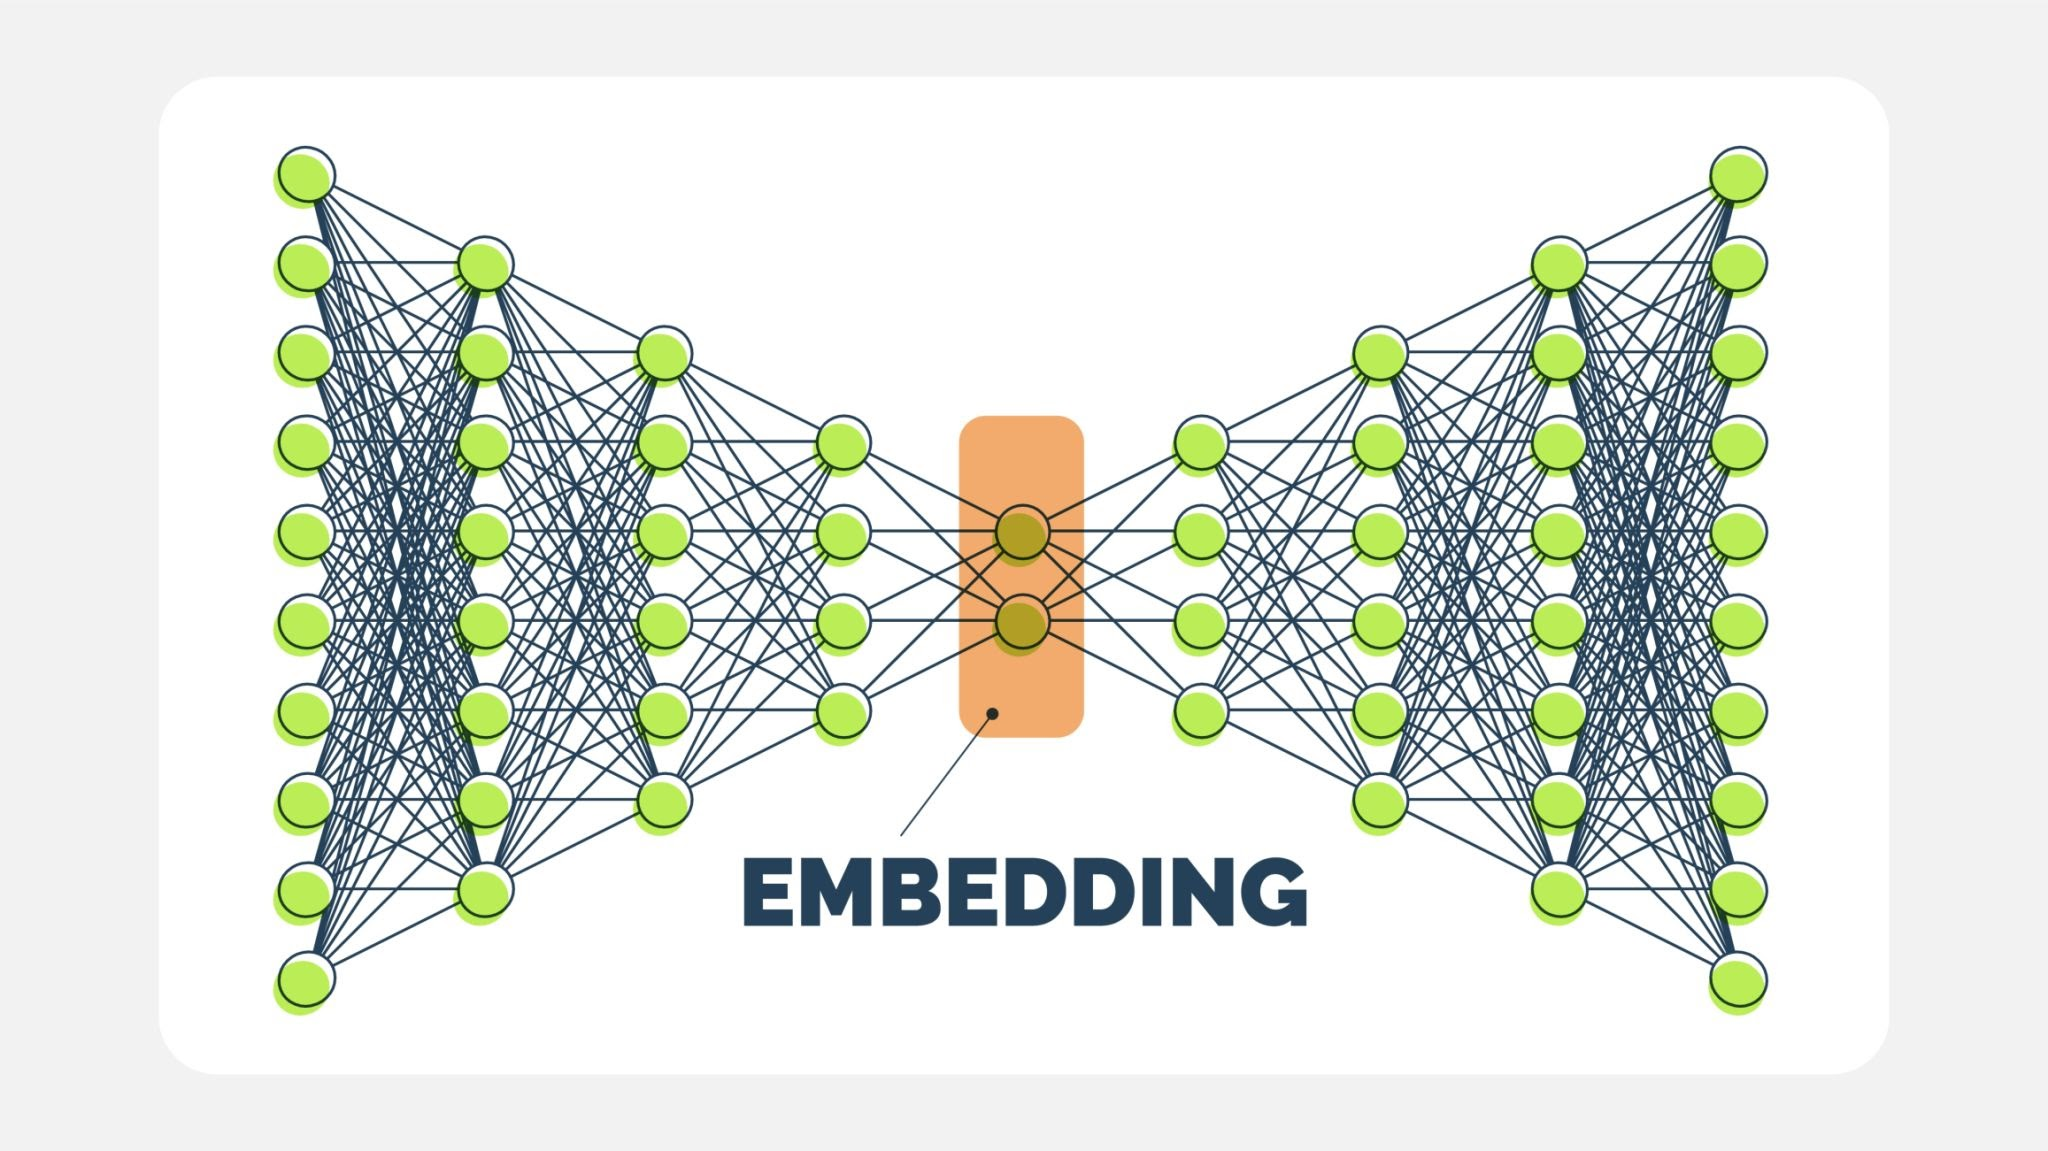


Section 2: Model Architecture (Undercomplete Autoencoder)

In [2]:
class ElectionAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(20, 14), nn.ReLU(),
            nn.Linear(14, 4),  nn.ReLU() # Bottleneck Layer
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 14),  nn.ReLU(),
            nn.Linear(14, 20), nn.Sigmoid() # Bound output between [0, 1]
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

In [3]:
# Feature selection and Tensors
feature_cols = [f'mp_{i}' for i in range(1, 11)] + [f'pl_{i}' for i in range(1, 11)]
X_tensor = torch.tensor(df[feature_cols].values / 100.0, dtype=torch.float32)

model = ElectionAutoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop: Learning the 'Normal' Political Landscape
for epoch in range(500):
    model.train()
    outputs, _ = model(X_tensor)
    loss = criterion(outputs, X_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Inference: Detecting Anomalies
model.eval()
with torch.no_grad():
    reconstructed, latent = model(X_tensor)
    # H1: Global Anomaly Score
    mse_per_district = torch.mean((reconstructed - X_tensor)**2, dim=1).numpy()
    # H2: Feature-wise residuals
    residuals = torch.abs(reconstructed - X_tensor).numpy()

df['anomaly_score'] = mse_per_district

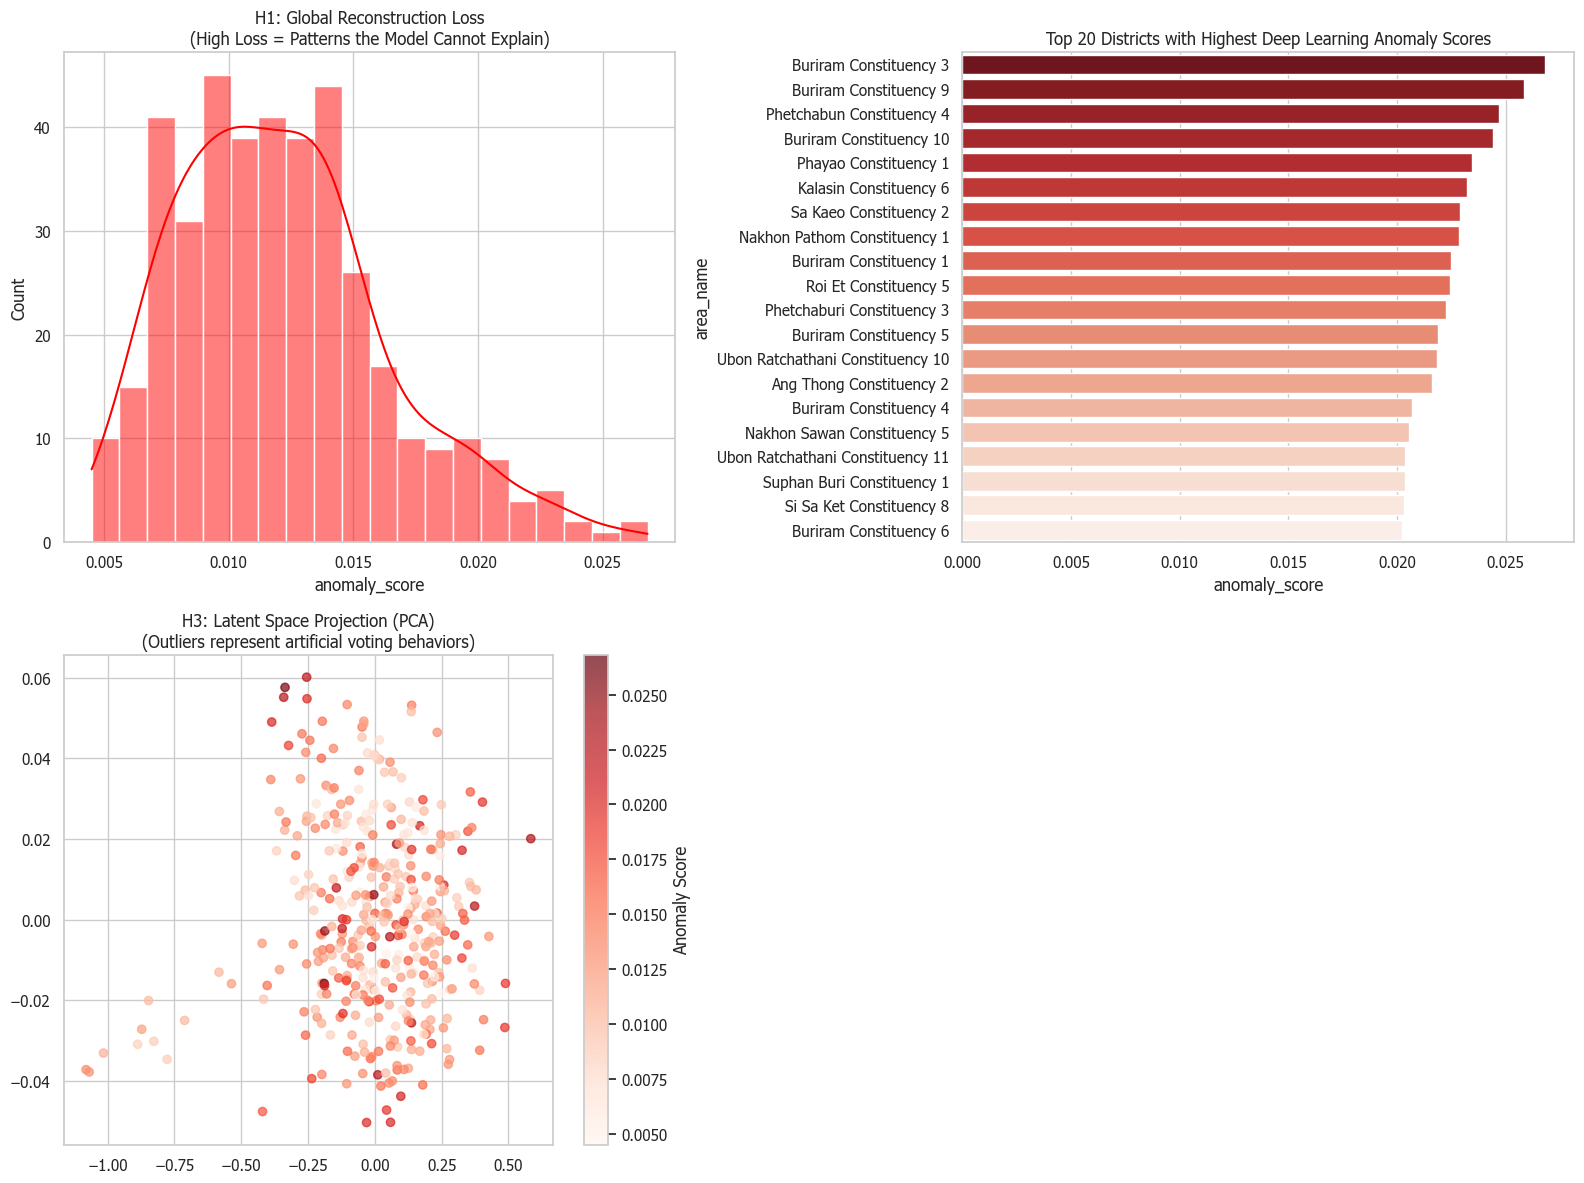

In [4]:
def plot_election_forensics(df, residuals, latent):
    sns.set(font='Tahoma', style='whitegrid')
    plt.figure(figsize=(16, 12))
    
    # 1. Global Anomaly Distribution
    plt.subplot(2, 2, 1)
    sns.histplot(df['anomaly_score'], bins=20, kde=True, color='red')
    plt.title("H1: Global Reconstruction Loss\n(High Loss = Patterns the Model Cannot Explain)")

    # 2. Top Suspected Districts (Fixing Seaborn Palette Warning)
    plt.subplot(2, 2, 2)
    top_20 = df.nlargest(20, 'anomaly_score')
    sns.barplot(data=top_20, x='anomaly_score', y='area_name', hue='area_name', palette='Reds_r', legend=False)
    plt.title("Top 20 Districts with Highest Deep Learning Anomaly Scores")

    # 3. Latent Space Projection (Manifold Analysis)
    if latent.shape[0] >= 2:
        z_pca = PCA(n_components=2).fit_transform(latent.numpy())
        plt.subplot(2, 2, 3)
        plt.scatter(z_pca[:, 0], z_pca[:, 1], c=df['anomaly_score'], cmap='Reds', alpha=0.7)
        plt.colorbar(label='Anomaly Score')
        plt.title("H3: Latent Space Projection (PCA)\n(Outliers represent artificial voting behaviors)")

    plt.tight_layout()
    plt.show()

plot_election_forensics(df, residuals, latent)